# 05 — Vision Transformer (ViT-B/16)
**WikiArt Painting Classifier** — NOVA IMS Deep Learning 2025/2026

This notebook fine-tunes a pretrained **Vision Transformer (ViT-B/16)** for 23-class artist classification on the WikiArt dataset. Unlike CNNs, ViT splits each image into 16x16 patches, treats them as tokens, and processes them through multi-head self-attention blocks — enabling the model to capture long-range compositional relationships across a painting.

The backbone is initialised from **ImageNet-21K** pretrained weights via `keras-hub`, with a custom classification head trained on our dataset.

This notebook covers:
1. Loading the pre-processed WikiArt dataset.
2. Building the ViT-B/16 model with a custom classification head.
3. Fine-tuning with Early Stopping and checkpointing.
4. Analysing learning curves and saving results.

In [4]:
import sys
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# Add the project root to the path
sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets
from src.models.vit import build_vit_model

# Global Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Smaller than CNNs due to ViT memory footprint (~86M params)
EPOCHS = 5
LEARNING_RATE = 3e-5
DROPOUT_RATE = 0.1

## 1. Loading the Pre-processed WikiArt Dataset
We reuse the shared `build_datasets` pipeline. Images are already resized to 224x224 and normalised to [0, 1]. The ViT model includes an inline ImageNet normalisation layer, so no changes to the data loader are needed.

In [5]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir="../data/splits",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    augment_train=True,
    use_processed=True,
    processed_dir="../data/processed"
)

# One-hot encode labels for categorical_crossentropy and F1Score
train_ds_oh = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))
val_ds_oh = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))
test_ds_oh = test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

print(f"Dataset loaded with {NUM_CLASSES} classes.")

Dataset loaded with 23 classes.


## 2. Model Architecture — ViT-B/16
The Vision Transformer splits each 224x224 image into a grid of **14x14 = 196 patches** (each 16x16 pixels). Each patch is linearly embedded and combined with a learnable positional encoding. A special `[CLS]` token is prepended to the sequence. The full sequence is then processed by **12 Transformer encoder blocks**, each containing multi-head self-attention (12 heads) and MLP layers with hidden dimension 768.

We load the pretrained backbone and attach:
- **Dropout** (0.1) on the `[CLS]` token output
- **Dense** (23 classes, softmax) classification head

In [6]:
model = build_vit_model(
    num_classes=NUM_CLASSES,
    input_shape=(224, 224, 3),
    learning_rate=LEARNING_RATE,
    dropout_rate=DROPOUT_RATE,
)

model.summary()

Model: "vit_b16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        17,687 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,816,343 (327.36 MB)

 Trainable params: 85,816,343 (327.36 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training with Early Stopping
We fine-tune the entire backbone with a low learning rate (3e-5) — standard for ViT fine-tuning. Early Stopping monitors `val_loss` with patience=5, and the best checkpoint is saved automatically.

In [7]:
os.makedirs('../results/logs', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.CSVLogger('../results/logs/vit.csv'),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='../results/models/vit_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
]

history = model.fit(
    train_ds_oh,
    validation_data=val_ds_oh,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3518 - f1_macro: 0.2702 - loss: 2.3784
Epoch 1: val_loss improved from None to 1.09191, saving model to ../results/models/vit_best.keras

Epoch 1: finished saving model to ../results/models/vit_best.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 1274s 2s/step - accuracy: 0.5186 - f1_macro: 0.4621 - loss: 1.8251 - val_accuracy: 0.7046 - val_f1_macro: 0.6569 - val_loss: 1.0919
Epoch 2/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7778 - f1_macro: 0.7463 - loss: 0.8769
Epoch 2: val_loss improved from 1.09191 to 0.72318, saving model to ../results/models/vit_best.keras

Epoch 2: finished saving model to ../results/models/vit_best.keras
584/584 ━━━━━━━━━━━━━━━━━━━━ 1236s 2s/step - accuracy: 0.7981 - f1_macro: 0.7747 - loss: 0.7858 - val_accuracy: 0.7976 - val_f1_macro: 0.7662 - val_loss: 0.7232
Epoch 3/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9080 - f1_macro: 0.8933 - loss: 0.4082
Epoch 3: val_loss improved from 0.

## 4. Learning Curves and Results
Visualise training vs. validation accuracy and loss to assess convergence and overfitting behaviour.

Figure saved to: ../results/figures\vit_learning_curves.png


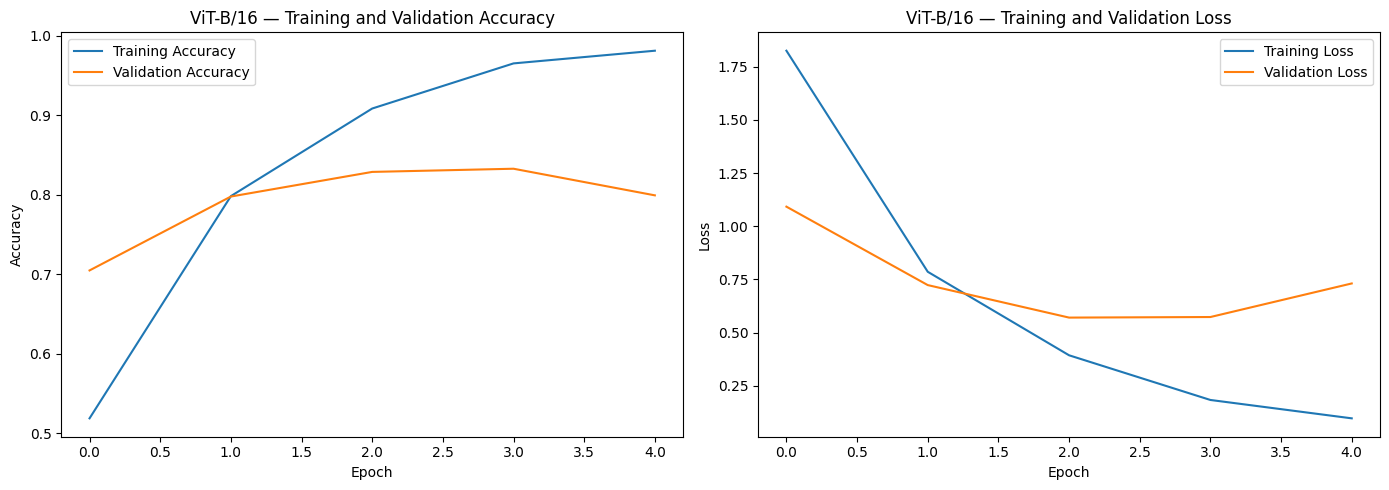

In [8]:
def plot_vit_results(history, filename="vit_learning_curves.png"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs_range, acc, label='Training Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
    axes[0].set_title('ViT-B/16 — Training and Validation Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(epochs_range, loss, label='Training Loss')
    axes[1].plot(epochs_range, val_loss, label='Validation Loss')
    axes[1].set_title('ViT-B/16 — Training and Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()

    os.makedirs('../results/figures', exist_ok=True)
    save_path = os.path.join('../results/figures', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")

    plt.show()

plot_vit_results(history)

In [9]:
# Save the final model
model.save('../results/models/vit.keras')
print("Final ViT model saved to ../results/models/vit.keras")

# Print final metrics
print(f"\nFinal Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training F1-macro:   {history.history['f1_macro'][-1]:.4f}")
print(f"Final Validation F1-macro: {history.history['val_f1_macro'][-1]:.4f}")

Final ViT model saved to ../results/models/vit.keras

Final Training Accuracy:   0.9810
Final Validation Accuracy: 0.7991
Final Training F1-macro:   0.9804
Final Validation F1-macro: 0.7817
